# Mock Data Science Interview: End-to-End Pipeline

## Scenario
You are interviewing for a quantitative developer/researcher role at a pod. They want to see your ability to handle a full data pipeline: **Cleaning -> EDA -> Strategy Implementation -> Predictive Modelling -> Analysis**.

## The Task
You are given synthetic daily data for a universe of 50 stocks over a 2-year period. 

### Objectives:
1.  **Data Cleaning**: Handle missing values.
2.  **EDA**: Visualize data distributions and correlations.
3.  **Strategy**: Construct a **Monthly Rebalanced Market-Cap Weighted Index**.
4.  **Modelling**: Build a simple model to predict future stock returns based on past returns (Momentum).
5.  **Analysis**: Compare strategy vs benchmark and discuss "next steps".


In [163]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import datetime as dt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller
import statsmodels.api as sm


# Plotting style
sns.set_theme(style="whitegrid")
%matplotlib inline


In [2]:
def generate_data(n_stocks=50, n_days=504):
    np.random.seed(42)
    dates = pd.date_range(start='2022-01-01', periods=n_days, freq='B')
    tickers = [f'STK_{i:02d}' for i in range(n_stocks)]
    
    # Generate prices with a slight Momentum factor (AR(1) process)
    # R_t = 0.1 * R_{t-1} + noise
    # This ensures our later modelling task has some signal to find.
    returns = np.zeros((n_days, n_stocks))
    noise = np.random.normal(0.0005, 0.02, (n_days, n_stocks))
    
    for t in range(1, n_days):
        returns[t] = 0.1 * returns[t-1] + noise[t]
        
    # Start price 100
    price_paths = 100 * np.cumprod(1 + returns, axis=0)
    
    # Generate shares outstanding
    base_shares = np.random.randint(1000, 10000, size=n_stocks)
    shares = np.tile(base_shares, (n_days, 1)).astype(float)
    
    # Introduce random corporate actions (share changes)
    for col in range(n_stocks):
        change_dates = np.random.choice(range(n_days), 2, replace=False)
        for d in change_dates:
            shares[d:, col] = shares[d:, col] * np.random.uniform(0.9, 1.1)

    # Create DataFrames
    df_prices = pd.DataFrame(price_paths, index=dates, columns=tickers)
    df_shares = pd.DataFrame(shares, index=dates, columns=tickers)
    
    # Introduce missing data
    for _ in range(50):
        r, c = np.random.randint(0, n_days-10), np.random.randint(0, n_stocks)
        df_prices.iloc[r:r+np.random.randint(3,6), c] = np.nan
        
    return df_prices, df_shares

df_prices, df_shares = generate_data()
print("Data Generated.")
display(df_prices.head())


Data Generated.


,STK_00,STK_01,STK_02,STK_03,STK_04,STK_05,STK_06,STK_07,STK_08,STK_09,...,STK_40,STK_41,STK_42,STK_43,STK_44,STK_45,STK_46,STK_47,STK_48,STK_49
2022-01-03,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,...,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000
2022-01-04,100.698168,99.279835,98.696156,101.273353,102.111999,101.912560,98.371565,99.431575,100.712527,102.001090,...,100.244155,101.987290,98.645894,99.394676,99.265784,97.122970,100.642241,100.572111,100.060227,99.580826
2022-01-05,97.968316,98.422746,97.940328,99.827960,102.049331,102.981988,101.971500,99.771943,101.353415,102.104333,...,100.774783,104.907201,95.390207,99.751239,99.758483,98.410765,98.267408,98.023913,101.160795,100.180354
2022-01-06,98.242523,99.068956,96.582257,100.199106,102.692250,101.670237,106.200770,100.801486,99.053734,103.506459,...,99.978565,107.056853,95.531528,97.351620,100.203403,99.348845,96.347575,98.125936,101.440412,98.000695
2022-01-07,99.022140,100.294662,98.588695,102.398258,99.978774,99.684590,107.788281,101.991712,99.898859,111.676002,...,98.364860,107.084085,96.558291,98.851759,97.892719,98.828575,95.292320,96.903041,105.100939,98.630241


## Part 1: Data Preprocessing

**Task**:
1.  Check for missing values.
2.  Fill missing price values using **forward fill** (then backward fill for any remaining at start).
3.  Calculate `df_returns` ($P_t / P_{t-1} - 1$).
4.  Calculate `df_mcap` ($Price 	imes Shares$).


In [9]:
# Missing values
df_prices =  df_prices.fillna(method='ffill')
df_prices =  df_prices.fillna(method='bfill')

df_prices

/var/folders/cf/zk37hd_50bv_nlrdlxrb4q3r0000gn/T/ipykernel_5608/658302312.py:2: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_prices =  df_prices.fillna(method='ffill')
/var/folders/cf/zk37hd_50bv_nlrdlxrb4q3r0000gn/T/ipykernel_5608/658302312.py:3: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_prices =  df_prices.fillna(method='bfill')


,STK_00,STK_01,STK_02,STK_03,STK_04,STK_05,STK_06,STK_07,STK_08,STK_09,...,STK_40,STK_41,STK_42,STK_43,STK_44,STK_45,STK_46,STK_47,STK_48,STK_49
2022-01-03,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,...,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000
2022-01-04,100.698168,99.279835,98.696156,101.273353,102.111999,101.912560,98.371565,99.431575,100.712527,102.001090,...,100.244155,101.987290,98.645894,99.394676,99.265784,97.122970,100.642241,100.572111,100.060227,99.580826
2022-01-05,97.968316,98.422746,97.940328,99.827960,102.049331,102.981988,101.971500,99.771943,101.353415,102.104333,...,100.774783,104.907201,95.390207,99.751239,99.758483,98.410765,98.267408,98.023913,101.160795,100.180354
2022-01-06,98.242523,99.068956,96.582257,100.199106,102.692250,101.670237,106.200770,100.801486,99.053734,103.506459,...,99.978565,107.056853,95.531528,97.351620,100.203403,99.348845,96.347575,98.125936,101.440412,98.000695
2022-01-07,99.022140,100.294662,98.588695,102.398258,99.978774,99.684590,107.788281,101.991712,99.898859,111.676002,...,98.364860,107.084085,96.558291,98.851759,97.892719,98.828575,95.292320,96.903041,105.100939,98.630241
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-12-01,196.234722,86.433223,105.059856,126.268105,78.002104,78.615180,116.165052,150.425484,106.997049,246.295310,...,56.064740,216.360650,92.421532,93.067192,143.752864,94.300096,189.232693,121.514779,172.887957,88.676703
2023-12-04,196.808412,86.416760,104.461588,126.155815,78.582921,78.213102,116.774446,147.589911,105.531095,243.399544,...,56.519163,213.551387,93.622680,92.290494,140.451990,93.737442,196.165411,126.163842,174.940321,88.493261
2023-12-05,198.160561,87.005950,104.371000,127.320227,79.007988,77.717943,114.102584,146.027491,107.126755,243.081914,...,55.427019,215.534952,94.869308,92.361092,138.808322,93.992974,198.029728,131.226122,172.183314,87.535310
2023-12-06,199.524253,86.663209,104.205307,130.226952,74.633757,76.778172,109.922385,142.453476,112.494290,246.079811,...,54.368726,220.688906,98.143148,90.529060,135.829649,94.140753,202.103785,128.842542,172.779816,86.450655


In [21]:
df_returns = df_prices/df_prices.shift(1)-1
df_returns = df_returns.dropna()
df_returns

,STK_00,STK_01,STK_02,STK_03,STK_04,STK_05,STK_06,STK_07,STK_08,STK_09,...,STK_40,STK_41,STK_42,STK_43,STK_44,STK_45,STK_46,STK_47,STK_48,STK_49
2022-01-04,0.006982,-0.007202,-0.013038,0.012734,0.021120,0.019126,-0.016284,-0.005684,0.007125,0.020011,...,0.002442,0.019873,-0.013541,-0.006053,-0.007342,-0.028770,0.006422,0.005721,0.000602,-0.004192
2022-01-05,-0.027109,-0.008633,-0.007658,-0.014272,-0.000614,0.010494,0.036595,0.003423,0.006364,0.001012,...,0.005293,0.028630,-0.033004,0.003587,0.004963,0.013259,-0.023597,-0.025337,0.010999,0.006021
2022-01-06,0.002799,0.006566,-0.013866,0.003718,0.006300,-0.012738,0.041475,0.010319,-0.022690,0.013732,...,-0.007901,0.020491,0.001481,-0.024056,0.004460,0.009532,-0.019537,0.001041,0.002764,-0.021757
2022-01-07,0.007936,0.012372,0.020774,0.021948,-0.026423,-0.019530,0.014948,0.011808,0.008532,0.078928,...,-0.016141,0.000254,0.010748,0.015409,-0.023060,-0.005237,-0.010953,-0.012463,0.036085,0.006424
2022-01-10,-0.023924,0.020094,0.045021,0.023344,-0.032530,-0.011138,0.027333,-0.012473,0.010230,0.023885,...,-0.005276,-0.009335,-0.010213,0.019033,0.005334,-0.013882,0.017397,0.005400,0.020366,0.013735
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-12-01,-0.009940,-0.009356,0.024286,-0.013388,-0.028707,-0.030913,-0.036494,-0.026170,-0.021230,0.024291,...,-0.004044,-0.014230,-0.002809,-0.018106,0.011755,-0.010876,-0.005441,0.019616,0.016404,0.001725
2023-12-04,0.002923,-0.000190,-0.005695,-0.000889,0.007446,-0.005115,0.005246,-0.018850,-0.013701,-0.011757,...,0.008105,-0.012984,0.012996,-0.008346,-0.022962,-0.005967,0.036636,0.038259,0.011871,-0.002069
2023-12-05,0.006870,0.006818,-0.000867,0.009230,0.005409,-0.006331,-0.022881,-0.010586,0.015120,-0.001305,...,-0.019323,0.009288,0.013315,0.000765,-0.011703,0.002726,0.009504,0.040125,-0.015760,-0.010825
2023-12-06,0.006882,-0.003939,-0.001588,0.022830,-0.055364,-0.012092,-0.036635,-0.024475,0.050105,0.012333,...,-0.019093,0.023912,0.034509,-0.019836,-0.021459,0.001572,0.020573,-0.018164,0.003464,-0.012391


In [22]:
df_mcap = df_shares*df_prices
df_mcap

,STK_00,STK_01,STK_02,STK_03,STK_04,STK_05,STK_06,STK_07,STK_08,STK_09,...,STK_40,STK_41,STK_42,STK_43,STK_44,STK_45,STK_46,STK_47,STK_48,STK_49
2022-01-03,314500.000000,919800.000000,795800.000000,527200.000000,282300.000000,498400.000000,9.822000e+05,9.461000e+05,477100.000000,150000.000000,...,366000.000000,8.930000e+05,805800.000000,726600.000000,9.955000e+05,907700.000000,440800.000000,730100.000000,8.494000e+05,268400.000000
2022-01-04,316695.738167,913175.926369,785424.009443,533913.114790,288262.173304,507932.200227,9.662055e+05,9.407221e+05,480499.465662,153001.635381,...,366893.607661,9.107465e+05,794888.612339,722201.713686,9.881909e+05,881585.199632,443630.996363,734276.979084,8.499116e+05,267274.936268
2022-01-05,308110.355209,905292.413747,779409.126872,526293.003873,288085.262430,513262.226071,1.001564e+06,9.439423e+05,483557.140675,153156.499343,...,368835.705330,9.368213e+05,768654.290703,724792.506081,9.930957e+05,893274.514706,433162.736151,715672.587319,8.592598e+05,268884.070153
2022-01-06,308972.735239,911236.253300,768601.599966,528249.684772,289900.222039,506724.460892,1.043104e+06,9.536829e+05,472585.366253,155259.688711,...,365921.547825,9.560177e+05,769793.050340,707356.868356,9.975249e+05,901789.466741,424700.111106,716417.459310,8.616349e+05,263033.864244
2022-01-07,311424.631771,922510.301718,784568.832492,539843.617205,282240.078436,496827.996440,1.058696e+06,9.649436e+05,476617.456128,167514.003491,...,360015.387008,9.562609e+05,778066.705493,718256.883916,9.745220e+05,897066.979555,420048.545412,707489.103387,8.927274e+05,264723.567173
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-12-01,714548.944419,883930.017800,872417.783501,684695.637038,216741.885488,426502.758595,1.069611e+06,1.365664e+06,530747.701856,379352.021246,...,211406.177296,1.967025e+06,738639.399070,800749.428888,1.328248e+06,795264.776073,859610.137499,850335.244830,1.431920e+06,229057.342190
2023-12-04,716637.920636,883761.656754,867449.764070,684086.741048,218355.782569,424321.408788,1.075222e+06,1.339921e+06,523475.985487,374891.869110,...,213119.694574,1.941484e+06,748239.060767,794066.717985,1.297749e+06,790519.722658,891102.765800,882868.425635,1.448919e+06,228583.500527
2023-12-05,721561.499039,889787.143641,866697.520990,690400.828120,219536.902692,421635.073210,1.050620e+06,1.325736e+06,531391.093091,374402.645119,...,209001.490396,1.959518e+06,758202.193618,794674.147556,1.282562e+06,792674.706671,899571.629160,918293.215561,1.426084e+06,226109.053074
2023-12-06,726527.104624,886282.026663,865321.604288,706162.700983,207382.370583,416536.629563,1.012130e+06,1.293289e+06,558016.188015,379020.102517,...,205010.931778,2.006375e+06,784366.954932,778911.353998,1.255039e+06,793920.983242,918078.473301,901613.412438,1.431024e+06,223307.323888


## Part 2: Exploratory Data Analysis (EDA)

**Task**:
1.  **Distribution**: Plot the histogram of daily returns for the entire universe (flattened).
2.  **Correlation**: Calculate the correlation matrix of returns for the first 5 stocks and plot a heatmap.
3.  **Outliers**: Identify if there are any returns > 10% or < -10%.


(array([2.000e+00, 4.000e+00, 2.000e+00, 0.000e+00, 4.000e+00, 2.000e+00,
        7.000e+00, 5.000e+00, 8.000e+00, 1.000e+01, 1.900e+01, 1.500e+01,
        3.200e+01, 2.800e+01, 3.800e+01, 4.900e+01, 6.400e+01, 7.300e+01,
        1.010e+02, 1.160e+02, 1.530e+02, 1.520e+02, 1.920e+02, 2.390e+02,
        2.820e+02, 3.150e+02, 4.100e+02, 4.200e+02, 4.740e+02, 5.330e+02,
        6.500e+02, 6.570e+02, 7.080e+02, 7.730e+02, 8.070e+02, 8.610e+02,
        8.420e+02, 9.230e+02, 9.130e+02, 1.027e+03, 1.166e+03, 9.910e+02,
        9.700e+02, 8.910e+02, 9.190e+02, 8.350e+02, 8.220e+02, 7.220e+02,
        7.530e+02, 6.080e+02, 6.190e+02, 5.550e+02, 5.210e+02, 4.260e+02,
        3.640e+02, 3.490e+02, 3.090e+02, 2.510e+02, 2.290e+02, 1.870e+02,
        1.340e+02, 1.390e+02, 1.060e+02, 8.400e+01, 6.200e+01, 5.400e+01,
        4.700e+01, 2.300e+01, 2.100e+01, 1.700e+01, 1.600e+01, 1.000e+01,
        8.000e+00, 1.000e+01, 4.000e+00, 3.000e+00, 2.000e+00, 3.000e+00,
        0.000e+00, 2.000e+00, 1.000e+0

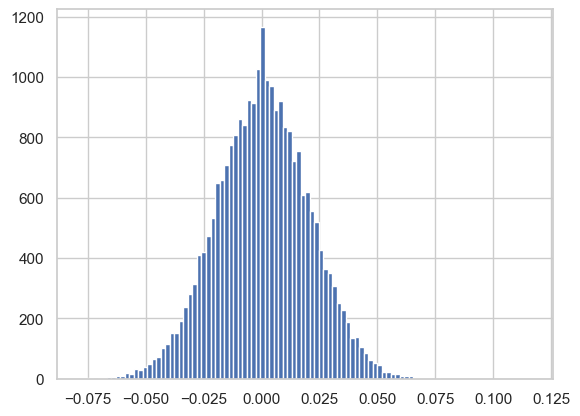

In [26]:
return_values = []
for col in df_returns.columns:
    series = df_returns[col].values
    return_values.extend(series) 

plt.hist(return_values, bins=100)

<Axes: >

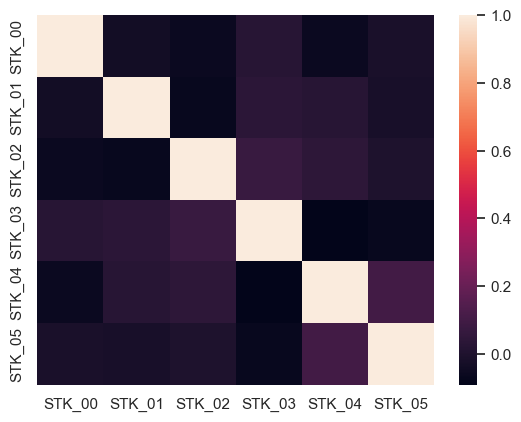

In [36]:
df_returns_5 = df_returns.iloc[:,:6]
corr_matrix = df_returns_5.corr()
sns.heatmap(corr_matrix)

there are clearly some outliers


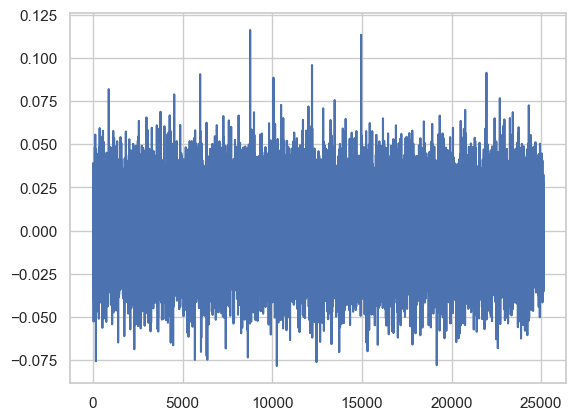

In [38]:
#checking for outliers
plt.plot(return_values)
print("there are clearly some outliers")

In [ ]:
returns_df.

{'whiskers': [<matplotlib.lines.Line2D at 0x176a8bc90>,
 'caps': [<matplotlib.lines.Line2D at 0x176a9ced0>,
 'boxes': [<matplotlib.lines.Line2D at 0x176a8b350>],
 'medians': [<matplotlib.lines.Line2D at 0x176a9e090>],
 'fliers': [<matplotlib.lines.Line2D at 0x176a9e850>],
 'means': []}

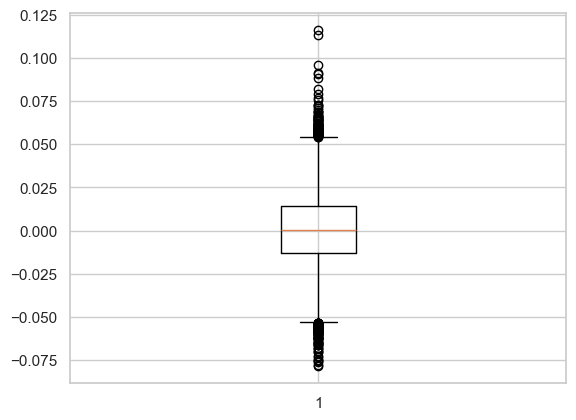

In [43]:
plt.boxplot(return_values)

Outliers on the topside but not on the bottom side 

## Part 3: Strategy Implementation (Index Construction)

**Goal**: Construct a **Monthly Rebalanced Market-Cap Weighted Index**.

**Steps**:
1.  **Resample Weights**: Calculate market cap weights at the **end of each month**.
2.  **Lag Weights**: Shift weights forward by 1 month (weights known at $t$ are used for $t+1$).
3.  **Broadcast**: Forward fill these monthly weights to daily frequency.
4.  **Calculate Index Return**: $\sum (w_{i,t-1} 	imes r_{i,t})$.


In [65]:
eom = []
df_mcap

,STK_00,STK_01,STK_02,STK_03,STK_04,STK_05,STK_06,STK_07,STK_08,STK_09,...,STK_40,STK_41,STK_42,STK_43,STK_44,STK_45,STK_46,STK_47,STK_48,STK_49
2022-01-03,314500.000000,919800.000000,795800.000000,527200.000000,282300.000000,498400.000000,9.822000e+05,9.461000e+05,477100.000000,150000.000000,...,366000.000000,8.930000e+05,805800.000000,726600.000000,9.955000e+05,907700.000000,440800.000000,730100.000000,8.494000e+05,268400.000000
2022-01-04,316695.738167,913175.926369,785424.009443,533913.114790,288262.173304,507932.200227,9.662055e+05,9.407221e+05,480499.465662,153001.635381,...,366893.607661,9.107465e+05,794888.612339,722201.713686,9.881909e+05,881585.199632,443630.996363,734276.979084,8.499116e+05,267274.936268
2022-01-05,308110.355209,905292.413747,779409.126872,526293.003873,288085.262430,513262.226071,1.001564e+06,9.439423e+05,483557.140675,153156.499343,...,368835.705330,9.368213e+05,768654.290703,724792.506081,9.930957e+05,893274.514706,433162.736151,715672.587319,8.592598e+05,268884.070153
2022-01-06,308972.735239,911236.253300,768601.599966,528249.684772,289900.222039,506724.460892,1.043104e+06,9.536829e+05,472585.366253,155259.688711,...,365921.547825,9.560177e+05,769793.050340,707356.868356,9.975249e+05,901789.466741,424700.111106,716417.459310,8.616349e+05,263033.864244
2022-01-07,311424.631771,922510.301718,784568.832492,539843.617205,282240.078436,496827.996440,1.058696e+06,9.649436e+05,476617.456128,167514.003491,...,360015.387008,9.562609e+05,778066.705493,718256.883916,9.745220e+05,897066.979555,420048.545412,707489.103387,8.927274e+05,264723.567173
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-12-01,714548.944419,883930.017800,872417.783501,684695.637038,216741.885488,426502.758595,1.069611e+06,1.365664e+06,530747.701856,379352.021246,...,211406.177296,1.967025e+06,738639.399070,800749.428888,1.328248e+06,795264.776073,859610.137499,850335.244830,1.431920e+06,229057.342190
2023-12-04,716637.920636,883761.656754,867449.764070,684086.741048,218355.782569,424321.408788,1.075222e+06,1.339921e+06,523475.985487,374891.869110,...,213119.694574,1.941484e+06,748239.060767,794066.717985,1.297749e+06,790519.722658,891102.765800,882868.425635,1.448919e+06,228583.500527
2023-12-05,721561.499039,889787.143641,866697.520990,690400.828120,219536.902692,421635.073210,1.050620e+06,1.325736e+06,531391.093091,374402.645119,...,209001.490396,1.959518e+06,758202.193618,794674.147556,1.282562e+06,792674.706671,899571.629160,918293.215561,1.426084e+06,226109.053074
2023-12-06,726527.104624,886282.026663,865321.604288,706162.700983,207382.370583,416536.629563,1.012130e+06,1.293289e+06,558016.188015,379020.102517,...,205010.931778,2.006375e+06,784366.954932,778911.353998,1.255039e+06,793920.983242,918078.473301,901613.412438,1.431024e+06,223307.323888


In [66]:
df_totalmcap =df_mcap.sum(axis=1)
df_totals = pd.DataFrame()

for col in df_mcap.columns:
    df_totals[col] = df_totalmcap
df_totals



,STK_00,STK_01,STK_02,STK_03,STK_04,STK_05,STK_06,STK_07,STK_08,STK_09,...,STK_40,STK_41,STK_42,STK_43,STK_44,STK_45,STK_46,STK_47,STK_48,STK_49
2022-01-03,2.918660e+07,2.918660e+07,2.918660e+07,2.918660e+07,2.918660e+07,2.918660e+07,2.918660e+07,2.918660e+07,2.918660e+07,2.918660e+07,...,2.918660e+07,2.918660e+07,2.918660e+07,2.918660e+07,2.918660e+07,2.918660e+07,2.918660e+07,2.918660e+07,2.918660e+07,2.918660e+07
2022-01-04,2.915173e+07,2.915173e+07,2.915173e+07,2.915173e+07,2.915173e+07,2.915173e+07,2.915173e+07,2.915173e+07,2.915173e+07,2.915173e+07,...,2.915173e+07,2.915173e+07,2.915173e+07,2.915173e+07,2.915173e+07,2.915173e+07,2.915173e+07,2.915173e+07,2.915173e+07,2.915173e+07
2022-01-05,2.910510e+07,2.910510e+07,2.910510e+07,2.910510e+07,2.910510e+07,2.910510e+07,2.910510e+07,2.910510e+07,2.910510e+07,2.910510e+07,...,2.910510e+07,2.910510e+07,2.910510e+07,2.910510e+07,2.910510e+07,2.910510e+07,2.910510e+07,2.910510e+07,2.910510e+07,2.910510e+07
2022-01-06,2.921267e+07,2.921267e+07,2.921267e+07,2.921267e+07,2.921267e+07,2.921267e+07,2.921267e+07,2.921267e+07,2.921267e+07,2.921267e+07,...,2.921267e+07,2.921267e+07,2.921267e+07,2.921267e+07,2.921267e+07,2.921267e+07,2.921267e+07,2.921267e+07,2.921267e+07,2.921267e+07
2022-01-07,2.926570e+07,2.926570e+07,2.926570e+07,2.926570e+07,2.926570e+07,2.926570e+07,2.926570e+07,2.926570e+07,2.926570e+07,2.926570e+07,...,2.926570e+07,2.926570e+07,2.926570e+07,2.926570e+07,2.926570e+07,2.926570e+07,2.926570e+07,2.926570e+07,2.926570e+07,2.926570e+07
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-12-01,3.873694e+07,3.873694e+07,3.873694e+07,3.873694e+07,3.873694e+07,3.873694e+07,3.873694e+07,3.873694e+07,3.873694e+07,3.873694e+07,...,3.873694e+07,3.873694e+07,3.873694e+07,3.873694e+07,3.873694e+07,3.873694e+07,3.873694e+07,3.873694e+07,3.873694e+07,3.873694e+07
2023-12-04,3.859188e+07,3.859188e+07,3.859188e+07,3.859188e+07,3.859188e+07,3.859188e+07,3.859188e+07,3.859188e+07,3.859188e+07,3.859188e+07,...,3.859188e+07,3.859188e+07,3.859188e+07,3.859188e+07,3.859188e+07,3.859188e+07,3.859188e+07,3.859188e+07,3.859188e+07,3.859188e+07
2023-12-05,3.869535e+07,3.869535e+07,3.869535e+07,3.869535e+07,3.869535e+07,3.869535e+07,3.869535e+07,3.869535e+07,3.869535e+07,3.869535e+07,...,3.869535e+07,3.869535e+07,3.869535e+07,3.869535e+07,3.869535e+07,3.869535e+07,3.869535e+07,3.869535e+07,3.869535e+07,3.869535e+07
2023-12-06,3.880272e+07,3.880272e+07,3.880272e+07,3.880272e+07,3.880272e+07,3.880272e+07,3.880272e+07,3.880272e+07,3.880272e+07,3.880272e+07,...,3.880272e+07,3.880272e+07,3.880272e+07,3.880272e+07,3.880272e+07,3.880272e+07,3.880272e+07,3.880272e+07,3.880272e+07,3.880272e+07


In [69]:
w = df_mcap/df_totals
w




,STK_00,STK_01,STK_02,STK_03,STK_04,STK_05,STK_06,STK_07,STK_08,STK_09,...,STK_40,STK_41,STK_42,STK_43,STK_44,STK_45,STK_46,STK_47,STK_48,STK_49
2022-01-03,0.010775,0.031514,0.027266,0.018063,0.009672,0.017076,0.033652,0.032416,0.016347,0.005139,...,0.012540,0.030596,0.027609,0.024895,0.034108,0.031100,0.015103,0.025015,0.029102,0.009196
2022-01-04,0.010864,0.031325,0.026943,0.018315,0.009888,0.017424,0.033144,0.032270,0.016483,0.005248,...,0.012586,0.031242,0.027267,0.024774,0.033898,0.030241,0.015218,0.025188,0.029155,0.009168
2022-01-05,0.010586,0.031104,0.026779,0.018082,0.009898,0.017635,0.034412,0.032432,0.016614,0.005262,...,0.012673,0.032188,0.026410,0.024903,0.034121,0.030691,0.014883,0.024589,0.029523,0.009238
2022-01-06,0.010577,0.031193,0.026311,0.018083,0.009924,0.017346,0.035707,0.032646,0.016177,0.005315,...,0.012526,0.032726,0.026351,0.024214,0.034147,0.030870,0.014538,0.024524,0.029495,0.009004
2022-01-07,0.010641,0.031522,0.026808,0.018446,0.009644,0.016976,0.036175,0.032972,0.016286,0.005724,...,0.012302,0.032675,0.026586,0.024543,0.033299,0.030653,0.014353,0.024175,0.030504,0.009046
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-12-01,0.018446,0.022819,0.022522,0.017676,0.005595,0.011010,0.027612,0.035255,0.013701,0.009793,...,0.005457,0.050779,0.019068,0.020671,0.034289,0.020530,0.022191,0.021952,0.036965,0.005913
2023-12-04,0.018570,0.022900,0.022478,0.017726,0.005658,0.010995,0.027861,0.034720,0.013564,0.009714,...,0.005522,0.050308,0.019389,0.020576,0.033628,0.020484,0.023090,0.022877,0.037545,0.005923
2023-12-05,0.018647,0.022995,0.022398,0.017842,0.005673,0.010896,0.027151,0.034261,0.013733,0.009676,...,0.005401,0.050640,0.019594,0.020537,0.033145,0.020485,0.023248,0.023731,0.036854,0.005843
2023-12-06,0.018724,0.022841,0.022301,0.018199,0.005345,0.010735,0.026084,0.033330,0.014381,0.009768,...,0.005283,0.051707,0.020214,0.020074,0.032344,0.020460,0.023660,0.023236,0.036879,0.005755


In [103]:
w_copy = w.copy()
w_copy *= np.NaN
w_copy

,STK_00,STK_01,STK_02,STK_03,STK_04,STK_05,STK_06,STK_07,STK_08,STK_09,...,STK_40,STK_41,STK_42,STK_43,STK_44,STK_45,STK_46,STK_47,STK_48,STK_49
2022-01-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2022-01-04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2022-01-05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2022-01-06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2022-01-07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-12-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2023-12-04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2023-12-05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2023-12-06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [109]:
df_w_index = w_copy.index
df_w_index


prev_idx = -1

for index, row in w_copy.iterrows():
    if prev_idx==-1:
        continue 

    # print(index)
    #change of month 
    prev_date = df_w_index[prev_idx]
    if index.month!=prev_date.month:
        w_copy.loc[index] = w.loc[prev_date]
    prev_idx+=1



In [111]:
w_monthly = w.resample('ME').last()


In [112]:
w_daily_strategy = w_monthly.reindex(w.index).ffill().shift(1)

In [113]:
w_daily_strategy

,STK_00,STK_01,STK_02,STK_03,STK_04,STK_05,STK_06,STK_07,STK_08,STK_09,...,STK_40,STK_41,STK_42,STK_43,STK_44,STK_45,STK_46,STK_47,STK_48,STK_49
2022-01-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2022-01-04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2022-01-05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2022-01-06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2022-01-07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-12-01,0.018658,0.023068,0.022019,0.017941,0.005769,0.011378,0.028699,0.036254,0.014019,0.009575,...,0.005488,0.051586,0.019149,0.021083,0.033939,0.020786,0.022345,0.02156,0.036421,0.005911
2023-12-04,0.018658,0.023068,0.022019,0.017941,0.005769,0.011378,0.028699,0.036254,0.014019,0.009575,...,0.005488,0.051586,0.019149,0.021083,0.033939,0.020786,0.022345,0.02156,0.036421,0.005911
2023-12-05,0.018658,0.023068,0.022019,0.017941,0.005769,0.011378,0.028699,0.036254,0.014019,0.009575,...,0.005488,0.051586,0.019149,0.021083,0.033939,0.020786,0.022345,0.02156,0.036421,0.005911
2023-12-06,0.018658,0.023068,0.022019,0.017941,0.005769,0.011378,0.028699,0.036254,0.014019,0.009575,...,0.005488,0.051586,0.019149,0.021083,0.033939,0.020786,0.022345,0.02156,0.036421,0.005911


In [114]:
w_daily_strategy = w_daily_strategy.dropna()

In [116]:
weighted_returns = w_daily_strategy*df_returns

weighted_returns = weighted_returns.dropna()

weighted_returns



,STK_00,STK_01,STK_02,STK_03,STK_04,STK_05,STK_06,STK_07,STK_08,STK_09,...,STK_40,STK_41,STK_42,STK_43,STK_44,STK_45,STK_46,STK_47,STK_48,STK_49
2022-02-01,-0.000097,0.000349,0.000287,0.000099,-0.000078,-0.000213,0.000064,0.000796,0.000217,-0.000048,...,0.000029,-0.000050,0.000422,0.000035,0.000501,0.000019,0.000049,-0.000958,0.000654,0.000090
2022-02-02,0.000207,-0.001896,0.001204,-0.000037,0.000187,-0.000386,0.000441,-0.000566,-0.000169,0.000233,...,-0.000061,0.000926,-0.000019,0.000079,-0.000051,0.000026,-0.000272,-0.000734,0.001041,-0.000134
2022-02-03,-0.000184,-0.001621,-0.000221,-0.000539,0.000305,0.000333,-0.000408,0.001372,0.000304,-0.000013,...,0.000024,-0.000777,-0.000284,0.000181,-0.001073,0.000279,-0.000026,0.000187,0.000254,0.000228
2022-02-04,0.000013,-0.000434,0.000060,0.000180,0.000043,0.000057,-0.000502,-0.000263,-0.000408,0.000216,...,-0.000080,-0.000196,-0.000301,-0.000478,-0.000533,-0.000685,0.000013,-0.000317,0.000181,-0.000243
2022-02-07,0.000077,0.000534,-0.001089,0.000183,0.000220,-0.000420,0.000000,0.000252,-0.000257,0.000018,...,0.000089,0.001653,-0.000021,0.000385,0.000020,-0.000112,0.000245,-0.000151,0.000194,0.000036
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-12-01,-0.000185,-0.000216,0.000535,-0.000240,-0.000166,-0.000352,-0.001047,-0.000949,-0.000298,0.000233,...,-0.000022,-0.000734,-0.000054,-0.000382,0.000399,-0.000226,-0.000122,0.000423,0.000597,0.000010
2023-12-04,0.000055,-0.000004,-0.000125,-0.000016,0.000043,-0.000058,0.000151,-0.000683,-0.000192,-0.000113,...,0.000044,-0.000670,0.000249,-0.000176,-0.000779,-0.000124,0.000819,0.000825,0.000432,-0.000012
2023-12-05,0.000128,0.000157,-0.000019,0.000166,0.000031,-0.000072,-0.000657,-0.000384,0.000212,-0.000012,...,-0.000106,0.000479,0.000255,0.000016,-0.000397,0.000057,0.000212,0.000865,-0.000574,-0.000064
2023-12-06,0.000128,-0.000091,-0.000035,0.000410,-0.000319,-0.000138,-0.001051,-0.000887,0.000702,0.000118,...,-0.000105,0.001234,0.000661,-0.000418,-0.000728,0.000033,0.000460,-0.000392,0.000126,-0.000073


In [123]:
#Sum returns 

returns_summed = weighted_returns.sum(axis=1)
returns_summed

index_returns = pd.DataFrame({'index_returns':returns_summed})

index_returns



,index_returns
2022-02-01,0.001465
2022-02-02,0.004975
2022-02-03,-0.001170
2022-02-04,-0.000715
2022-02-07,0.001661
...,...
2023-12-01,0.001444
2023-12-04,-0.003696
2023-12-05,0.002550
2023-12-06,0.002706


In [125]:
#Summing the index returns 

sum(index_returns['index_returns'])

0.2535994254522439

In [ ]:
# Your code here: Monthly weights

# Your code here: Shift & Broadcast to daily

# Your code here: Index Daily Return


## Part 4: Benchmark & Performance

**Task**:
1.  Create an **Equal-Weighted Index** (daily rebalanced for simplicity, weight = $1/N$).
2.  Plot **Cumulative Returns** of MC-Weighted Strategy vs Equal-Weighted Benchmark.
3.  Calculate **Sharpe Ratio** for both (assume $Rf=0$).
    *   $Sharpe = 
rac{Mean(R) 	imes 252}{Std(R) 	imes \sqrt{252}}$


CS_SR = 0.16445252866180948, NI_SR = 0.20296783899534115


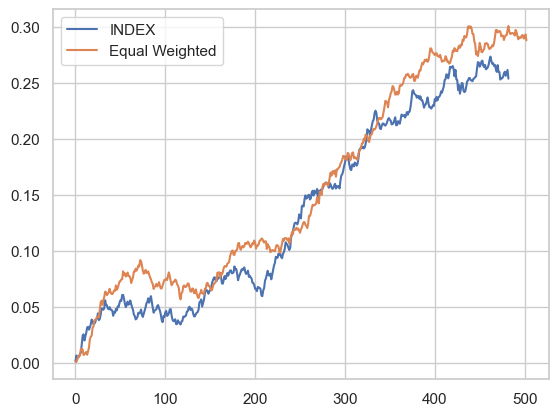

In [134]:
# Your code here: Equal Weighted Index
equal_weighted_returns = (df_returns*(1/50)).sum(axis=1)

sum(equal_weighted_returns)



# Your code here: Plot Cumulative Returns

index = index_returns['index_returns'].values
cs_index = np.cumsum(index)
naive = equal_weighted_returns.values
naive_index = np.cumsum(naive)



plt.plot(cs_index, label='INDEX')
plt.plot(naive_index, label='Equal Weighted')
plt.legend()

# Your code here: Calculate Sharpe Ratios


cs_SR = index_returns['index_returns'].mean()/(index_returns['index_returns'].std())
ni_SR = equal_weighted_returns.mean()/(equal_weighted_returns.std())


print(f'CS_SR = {cs_SR}, NI_SR = {ni_SR}')



## Part 5: Predictive Modelling

**Scenario**: The PM asks, *"Can we predict tomorrow's return based on today's return to improve our execution?"*

**Task**:
1.  **Feature Engineering**: Create a dataset for **Stock 0** (`STK_00`) containing:
    *   `Lag_1`: Return at $t-1$.
    *   `Lag_2`: Return at $t-2$.
    *   Target `Y`: Return at $t$.
2.  **Train/Test Split**: Split chronologically (first 80% train, last 20% test).
3.  **Model**: Train a Linear Regression model.
4.  **Evaluation**: Print the Coefficients and RMSE (Root Mean Squared Error) on the test set.


In [164]:
# Your code here: Create Lag Features for STK_00
stk_00 = df_returns['STK_00']
stk_00_l1 = stk_00.shift(1)
stk_00_l2 = stk_00.shift(2)


stk_00_df = pd.DataFrame({'Return':stk_00.values,'Lag1':stk_00_l1.values, 'Lag2':stk_00_l2.values})
stk_00_df = stk_00_df.dropna()


#testing stationarity


# Your code here: Split Train/Test
stk_00_df 

result = adfuller(stk_00_df['Return'])
print(result)



length = len(stk_00_df)

print(length)
train, test = stk_00_df.iloc[:int(length*0.8)], stk_00_df.iloc[int(length*0.8):]

# Your code here: Train Model
X = sm.add_constant(train[['Lag1','Lag2']])
Y = train['Return']

model = sm.OLS(Y,X).fit()

print(model.summary())


# Your code here: Evaluate





(-19.903201194775875, 0.0, 0, 500, {'1%': -3.443496379464, '5%': -2.8673378563200003, '10%': -2.569858036}, -2386.9162379234413)
501
                            OLS Regression Results                            
Dep. Variable:                 Return   R-squared:                       0.005
Model:                            OLS   Adj. R-squared:                 -0.000
Method:                 Least Squares   F-statistic:                    0.9610
Date:                Sun, 21 Dec 2025   Prob (F-statistic):              0.383
Time:                        14:16:29   Log-Likelihood:                 989.69
No. Observations:                 400   AIC:                            -1973.
Df Residuals:                     397   BIC:                            -1961.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975

## Bonus: Turnover & Transaction Costs

**Task**:
1.  Calculate **Monthly Turnover** for the MC-Weighted Index.
    *   $Turnover_t = 
rac{1}{2} \sum |w_{new} - w_{old}|$
2.  **Discussion**: If transaction costs are 10bps (0.10%) one-way, how much drag does this add to the annual return?


In [ ]:
# Your code here: Calculate Turnover


## Part 6: Next Steps & System Design

**Interview Question**:
*"If you were to productionize this pipeline, what components would you add? How would you handle data updates, backfilling, and execution slippage?"*

**Write your answer below (Bullet points):**
